In [ ]:
%pip install git+https://github.com/ProvideQ/super-hubo.git

---

We set up a helper function that generates Minimum Set Cover instances.
It first guarantees that every item is present in a (randomly chosen) subset.
It then includes each item in each subset according to the inclusion chance.

In [ ]:
from super_hubo.utils import *
import random
from itertools import combinations

random.seed("super_hubo")

def generate_set_cover(universe_size: int, subset_num: int, inclusion_chance: float):
    universe = list(range(universe_size))
    subsets = [[] for _ in range(subset_num)]

    # make sure the subsets' union is actually the universe
    for item in universe:
        subsets[random.randrange(0,subset_num)].append(item)

    for subset in subsets:
        for item in universe:
            if random.random() < inclusion_chance and item not in subset:
                subset.append(item)

    return universe, subsets

---
# RQ3: Combinatorial Optimization Problem conversion

### Sparse Problems

We generate 10,000 "sparse" problem instances of universe size 10 with 8 subsets and a 10% inclusion chance.

We create both a `super_hubo` `MinimumSetCover` and a `qubovert` `SetCover` instance and convert them to HUBO and QUBO respectively.

We also take note of problem statistics, i.e. number of terms, number of binary variables and polynomial degree for HUBO.

In [ ]:
from super_hubo.problem.minimumSetCover import MinimumSetCover as HuboSetCover
from qubovert.problems import SetCover as QuboSetCover

qsc_instances = []
hsc_instances = []

qubo_instances = []
hubo_instances = []

qubo_properties = []
hubo_properties = []

for _ in range(10000):
    u, s = generate_set_cover(10,8,0.1)

    qsc = QuboSetCover(u, s)
    hsc = HuboSetCover(u, s)

    qsc_instances.append(qsc)
    hsc_instances.append(hsc)

    qubo = qsc.to_qubo()
    hubo = hsc.to_pubo()

    qubo_instances.append(qubo)
    hubo_instances.append(hubo)

    qubo_properties.append([qubo.num_terms, qubo.num_binary_variables])
    hubo_properties.append([hubo.num_terms, hubo.num_binary_variables, hubo.degree])


We calculate mean, min and max of the previously collected statistics and print them, as well as prepare some objects for plotting.

In [ ]:
import numpy as np

average_qubo = np.mean(qubo_properties, axis = 0)
average_hubo = np.mean(hubo_properties, axis = 0)

min_qubo = np.min(qubo_properties, axis=0)
max_qubo = np.max(qubo_properties, axis=0)
min_hubo = np.min(hubo_properties, axis=0)
max_hubo = np.max(hubo_properties, axis=0)

print(f"QUBO instances have an average of {average_qubo[0]:.1f} terms consisting of {average_qubo[1]:.1f} variables.")
print(f"The benchmark problem instances have a minimum of {min_qubo[0]} terms and {min_qubo[1]} variables, and a maximum of {max_qubo[0]} terms and {max_qubo[1]} variables.")
print(f"HUBO instances have an average of {average_hubo[0]:.1f} terms consisting of {average_hubo[1]:.1f} variables.")
print(f"The benchmark problem instances have a minimum of {min_hubo[0]} terms and {min_hubo[1]} variables, and a maximum of {max_hubo[0]} terms and {max_hubo[1]} variables.")
print(f"HUBO instances have an average degree of {average_hubo[2]:.1f} with min degree of {min_hubo[2]} and maximum of {max_hubo[2]}.")

hubo_degrees = [average_hubo[2], min_hubo[2], max_hubo[2]]
average_hubo = average_hubo[:2]
min_hubo = min_hubo[:2]
max_hubo = max_hubo[:2]

mins = np.array([min_qubo, min_hubo]).T
maxs = np.array([max_qubo, max_hubo]).T

QUBO instances have an average of 141.8 terms consisting of 40.3 variables.
The benchmark problem instances have a minimum of 59 terms and 28 variables, and a maximum of 245 terms and 48 variables.
HUBO instances have an average of 16.8 terms consisting of 7.4 variables.
The benchmark problem instances have a minimum of 3 terms and 3 variables, and a maximum of 128 terms and 8 variables.
HUBO instances have an average degree of 3.1 with min degree of 1 and maximum of 7.


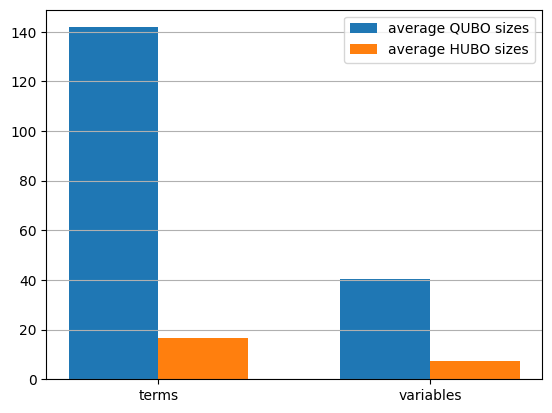

In [ ]:
import matplotlib.pyplot as plt

labels = ["terms", "variables"]

x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, average_qubo, width, label="average QUBO sizes")
plt.bar(x + width/2, average_hubo, width, label="average HUBO sizes")

plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.show()

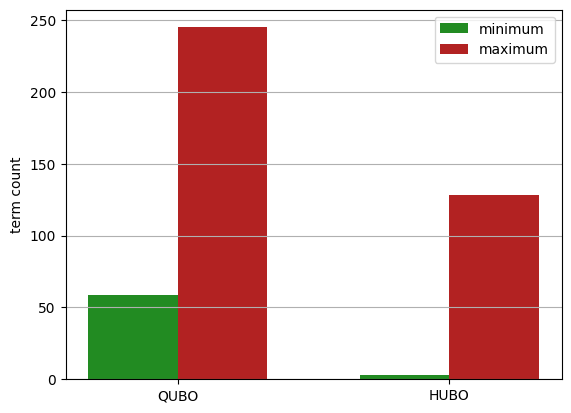

In [ ]:
import matplotlib.pyplot as plt

labels = ["QUBO", "HUBO"]

x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, mins[0], width, label="minimum",color="forestgreen")
plt.bar(x + width/2, maxs[0], width, label="maximum",color="firebrick")

plt.ylabel("term count")
plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.show()

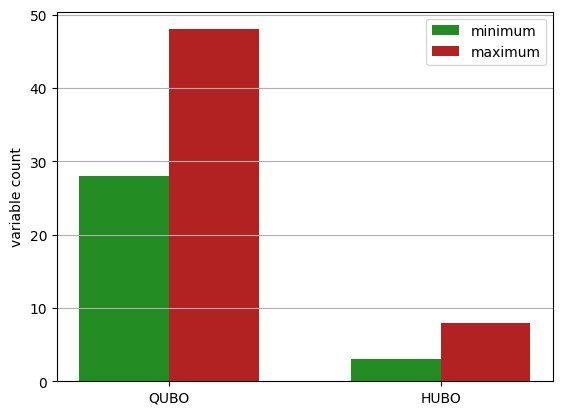

In [ ]:
import matplotlib.pyplot as plt


x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, mins[1], width, label="minimum", color="forestgreen")
plt.bar(x + width/2, maxs[1], width, label="maximum", color="firebrick")

plt.ylabel("variable count")
plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.show()

Let's look at the smallest instance to understand why it produces such a small hubo instance:

In [ ]:
index = np.argmin(hubo_properties, axis=0)[0]
print(hsc_instances[index])
print(hubo_instances[index].pretty_str())


MinimumSetCover([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [[9], [8], [6], [1, 6], [2, 4, 5], [3], [7], [0]])
-x(y3) - 2 x(y4) + x(y2) x(y3)
[3 3 1]


---
### Dense Problems

We create another 1000 Minimum Set Cover instances and convert to HUBO and QUBO, this time with 40% inclusion chance.

In [ ]:
from super_hubo.problem.minimumSetCover import MinimumSetCover as HuboSetCover
from qubovert.problems import SetCover as QuboSetCover

d_qsc_instances = []
d_hsc_instances = []

d_qubo_instances = []
d_hubo_instances = []

d_qubo_properties = []
d_hubo_properties = []

for i in range(1000):

    u, s = generate_set_cover(10,8,0.4)

    d_qsc = QuboSetCover(u, s)
    d_hsc = HuboSetCover(u, s)

    d_qsc_instances.append(d_qsc)
    d_hsc_instances.append(d_hsc)

    d_qubo = d_qsc.to_qubo()
    d_hubo = d_hsc.to_pubo()

    d_qubo_instances.append(d_qubo)
    d_hubo_instances.append(d_hubo)

    d_qubo_properties.append([d_qubo.num_terms, d_qubo.num_binary_variables])
    d_hubo_properties.append([d_hubo.num_terms, d_hubo.num_binary_variables, d_hubo.degree])


In [ ]:
import numpy as np

average_d_qubo = np.mean(d_qubo_properties, axis = 0)
average_d_hubo = np.mean(d_hubo_properties, axis = 0)

min_d_qubo = np.min(d_qubo_properties, axis=0)
max_d_qubo = np.max(d_qubo_properties, axis=0)
min_d_hubo = np.min(d_hubo_properties, axis=0)
max_d_hubo = np.max(d_hubo_properties, axis=0)


print(f"QUBO instances have an average of {average_d_qubo[0]:.1f} terms consisting of {average_d_qubo[1]:.1f} variables.")
print(f"The benchmark problem instances have a minimum of {min_d_qubo[0]} terms and {min_d_qubo[1]} variables, and a maximum of {max_d_qubo[0]} terms and {max_d_qubo[1]} variables.")
print(f"HUBO instances have an average of {average_d_hubo[0]:.1f} terms consisting of {average_d_hubo[1]:.1f} variables.")
print(f"The benchmark problem instances have a minimum of {min_d_hubo[0]} terms and {min_d_hubo[1]} variables, and a maximum of {max_d_hubo[0]} terms and {max_d_hubo[1]} variables.")
print(f"HUBO instances have an average degree of {average_d_hubo[2]:.1f} with min degree of {min_d_hubo[2]} and maximum of {max_d_hubo[2]}.")

d_hubo_degrees = [average_d_hubo[2], min_d_hubo[2], max_d_hubo[2]]
average_d_hubo = average_d_hubo[:2]
min_d_hubo = min_d_hubo[:2]
max_d_hubo = max_d_hubo[:2]

d_mins = np.array([min_d_qubo, min_d_hubo]).T
d_maxs = np.array([max_d_qubo, max_d_hubo]).T


QUBO instances have an average of 287.8 terms consisting of 48.2 variables.
The benchmark problem instances have a minimum of 228 terms and 48 variables, and a maximum of 437 terms and 58 variables.
HUBO instances have an average of 106.7 terms consisting of 8.0 variables.
The benchmark problem instances have a minimum of 36 terms and 7 variables, and a maximum of 255 terms and 8 variables.
HUBO instances have an average degree of 5.8 with min degree of 4 and maximum of 8.


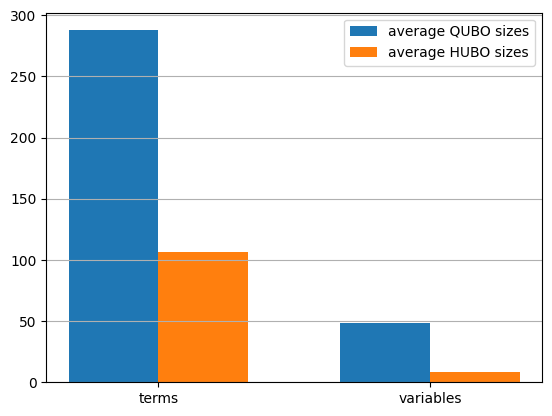

In [ ]:
import matplotlib.pyplot as plt

labels = ["terms", "variables"]

x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, average_d_qubo, width, label="average QUBO sizes")
plt.bar(x + width/2, average_d_hubo, width, label="average HUBO sizes")

plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.show()

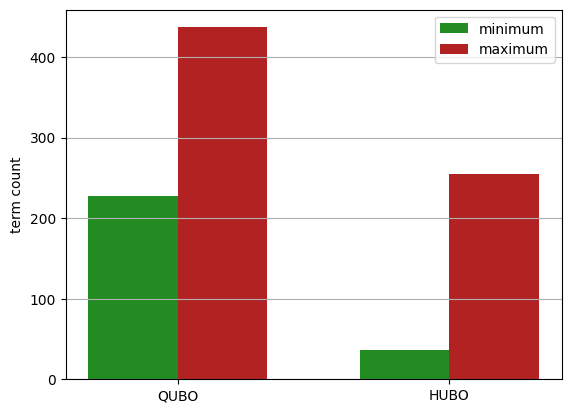

In [ ]:
import matplotlib.pyplot as plt

labels = ["QUBO", "HUBO"]

x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, d_mins[0], width, label="minimum", color="forestgreen")
plt.bar(x + width/2, d_maxs[0], width, label="maximum", color="firebrick")

plt.ylabel("term count")
plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.savefig("graph_p_d_terms", dpi=300)
plt.show()

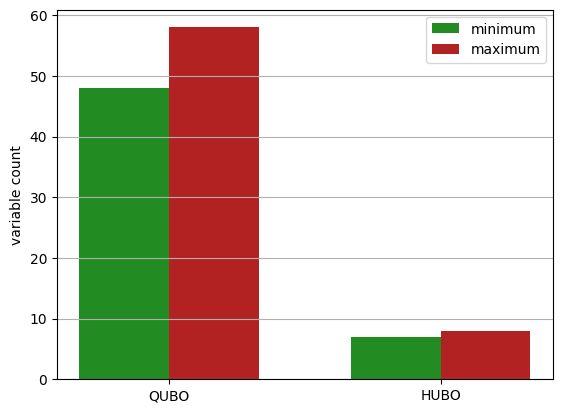

In [ ]:
import matplotlib.pyplot as plt

plt.bar(x - width/2, d_mins[1], width, label="minimum", color="forestgreen")
plt.bar(x + width/2, d_maxs[1], width, label="maximum", color="firebrick")

plt.ylabel("variable count")
plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.savefig("graph_p_d_vars", dpi=300)
plt.show()

---

### Average HUBO degree

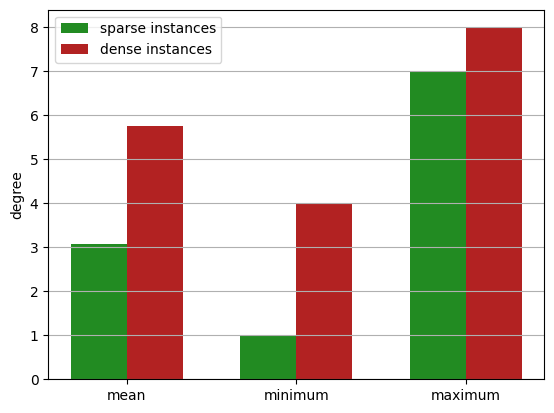

sparse HUBO instances have an average degree of 3.1 with min degree of 1 and maximum of 7.
dense HUBO instances have an average degree of 5.8 with min degree of 4 and maximum of 8.


In [ ]:
import matplotlib.pyplot as plt

labels = ["mean", "minimum","maximum"]

x = np.arange(len(labels))
width = 0.33

plt.bar(x - width/2, hubo_degrees, width, label="sparse instances", color="forestgreen")
plt.bar(x + width/2, d_hubo_degrees, width, label="dense instances", color="firebrick")

plt.ylabel("degree")
plt.xticks(x,labels)
plt.grid(axis="y")
plt.legend()

plt.savefig("graph_p_d_vars", dpi=300)
plt.show()

print(f"sparse HUBO instances have an average degree of {hubo_degrees[0]:.1f} with min degree of {hubo_degrees[1]} and maximum of {hubo_degrees[2]}.")
print(f"dense HUBO instances have an average degree of {d_hubo_degrees[0]:.1f} with min degree of {d_hubo_degrees[1]} and maximum of {d_hubo_degrees[2]}.")